# 03 - Exploratory Data Analysis

This notebook performs EDA for `data/Restaurant_ABSA_processed.csv`.

Main goals:
- inspect dataset shape, schema, missing values, and duplicate rows
- analyze aspect-label distribution and multi-label combinations
- inspect text length and vocabulary statistics
- detect suspicious records that may need manual relabeling
- save reusable EDA summary files to `outputs/EDA/`


## 1. Setup


In [ ]:
from pathlib import Path
from collections import Counter
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import wordcloud

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
except ImportError:
    sns = None

DATA_PATH = Path("../data/Restaurant_ABSA_processed.csv")
OUTPUT_DIR = Path("../outputs/EDA")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ASPECT_COLUMNS = ["food", "price", "service", "ambiance", "miscellaneous"]

pd.set_option("display.max_colwidth", 160)
pd.set_option("display.max_columns", 50)


## 2. Load Data


In [16]:
df = pd.read_csv(DATA_PATH)
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")
df.head()


Rows: 796
Columns: 7


,review_en,review_cleaned,food,price,service,ambiance,miscellaneous
0,the food was very tasty but the price was high,food tasty price high,1,1,0,0,0
1,although the food was good but the ambience was bad,although food good ambience bad,1,0,0,1,0
2,food always tastes fresh and served promptly,food always taste fresh served promptly,1,0,1,0,0
3,very good price and very good service,good price good service,0,1,1,0,0
4,it is a pretty relaxing place now the food is good,pretty relaxing place food good,1,0,0,1,0


In [17]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 796 entries, 0 to 795
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   review_en       796 non-null    str  
 1   review_cleaned  796 non-null    str  
 2   food            796 non-null    int64
 3   price           796 non-null    int64
 4   service         796 non-null    int64
 5   ambiance        796 non-null    int64
 6   miscellaneous   796 non-null    int64
dtypes: int64(5), str(2)
memory usage: 132.1 KB


## 3. Schema And Data Quality Checks


In [18]:
expected_columns = ["review_en", "review_cleaned", *ASPECT_COLUMNS]
missing_expected = [col for col in expected_columns if col not in df.columns]
extra_columns = [col for col in df.columns if col not in expected_columns]

schema_summary = pd.DataFrame({
    "column": df.columns,
    "dtype": [str(df[col].dtype) for col in df.columns],
    "missing_count": [df[col].isna().sum() for col in df.columns],
    "missing_pct": [df[col].isna().mean() * 100 for col in df.columns],
    "unique_count": [df[col].nunique(dropna=True) for col in df.columns],
})

print("Missing expected columns:", missing_expected)
print("Extra columns:", extra_columns)
schema_summary


Missing expected columns: []
Extra columns: []


,column,dtype,missing_count,missing_pct,unique_count
0,review_en,str,0,0.0,796
1,review_cleaned,str,0,0.0,789
2,food,int64,0,0.0,2
3,price,int64,0,0.0,2
4,service,int64,0,0.0,2
5,ambiance,int64,0,0.0,2
6,miscellaneous,int64,0,0.0,2


In [19]:
label_value_summary = {}
for col in ASPECT_COLUMNS:
    label_value_summary[col] = df[col].value_counts(dropna=False).sort_index()

label_values_df = pd.DataFrame(label_value_summary).fillna(0).astype(int)
label_values_df


,food,price,service,ambiance,miscellaneous
0,140,392,569,595,747
1,656,404,227,201,49


In [20]:
invalid_label_rows = df[
    ~df[ASPECT_COLUMNS].isin([0, 1]).all(axis=1)
].copy()

print(f"Rows with non-binary aspect labels: {len(invalid_label_rows):,}")
invalid_label_rows.head(20)


Rows with non-binary aspect labels: 0


,review_en,review_cleaned,food,price,service,ambiance,miscellaneous


In [21]:
duplicate_review_count = df.duplicated(subset=["review_en"]).sum()
duplicate_full_count = df.duplicated().sum()

print(f"Duplicate review_en rows: {duplicate_review_count:,}")
print(f"Fully duplicated rows: {duplicate_full_count:,}")

duplicate_reviews = (
    df[df.duplicated(subset=["review_en"], keep=False)]
    .sort_values("review_en")
    .reset_index()
    .rename(columns={"index": "row_id"})
)
duplicate_reviews.head(30)


Duplicate review_en rows: 0
Fully duplicated rows: 0


,row_id,review_en,review_cleaned,food,price,service,ambiance,miscellaneous


## 4. Aspect Label Distribution


In [22]:
aspect_counts = df[ASPECT_COLUMNS].sum().sort_values(ascending=False)
aspect_pct = (aspect_counts / len(df) * 100).round(2)

aspect_distribution = pd.DataFrame({
    "aspect": aspect_counts.index,
    "positive_count": aspect_counts.values.astype(int),
    "positive_pct": aspect_pct.values,
})
aspect_distribution


,aspect,positive_count,positive_pct
0,food,656,82.41
1,price,404,50.75
2,service,227,28.52
3,ambiance,201,25.25
4,miscellaneous,49,6.16


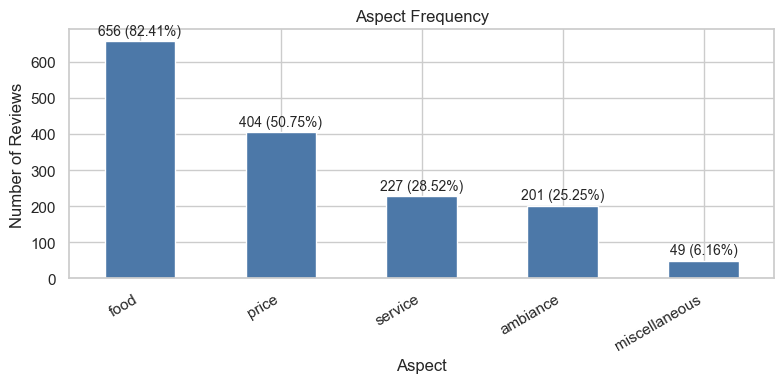

In [23]:
ax = aspect_distribution.plot(
    x="aspect",
    y="positive_count",
    kind="bar",
    legend=False,
    figsize=(8, 4),
    color="#4C78A8",
)

ax.set_title("Aspect Frequency")
ax.set_xlabel("Aspect")
ax.set_ylabel("Number of Reviews")

plt.xticks(rotation=30, ha="right")

# Hiển thị số lượng và tỷ lệ phần trăm trên từng cột
for i, row in aspect_distribution.iterrows():
    ax.text(
        i,
        row["positive_count"] + 10,
        f'{row["positive_count"]} ({row["positive_pct"]:.2f}%)',
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

In [24]:
df["label_count"] = df[ASPECT_COLUMNS].sum(axis=1)
label_count_distribution = (
    df["label_count"].value_counts().sort_index().rename_axis("label_count").reset_index(name="review_count")
)
label_count_distribution


,label_count,review_count
0,1,59
1,2,733
2,3,4


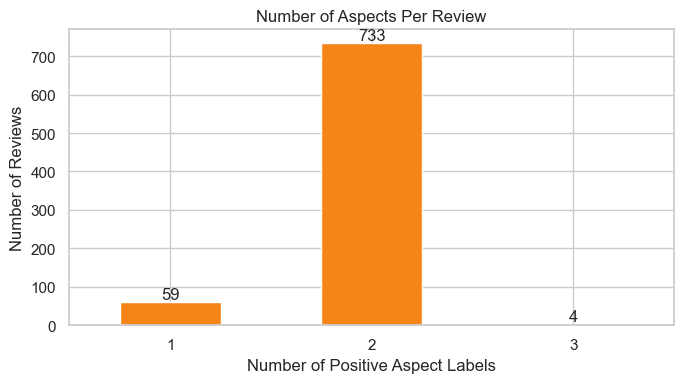

In [47]:
ax = label_count_distribution.plot(
    x="label_count",
    y="review_count",
    kind="bar",
    legend=False,
    figsize=(7, 4),
    color="#F58518",
)
plt.xticks(rotation=0)
ax.bar_label(ax.containers[0])
ax.set_title("Number of Aspects Per Review")
ax.set_xlabel("Number of Positive Aspect Labels")
ax.set_ylabel("Number of Reviews")
plt.tight_layout()
plt.show()


In [26]:
combo_df = df[ASPECT_COLUMNS].astype(str)
df["aspect_combo"] = combo_df.apply(
    lambda row: ", ".join([aspect for aspect in ASPECT_COLUMNS if row[aspect] == "1"]) or "none",
    axis=1,
)

combo_distribution = (
    df["aspect_combo"]
    .value_counts()
    .rename_axis("aspect_combo")
    .reset_index(name="review_count")
)
combo_distribution.head(20)


,aspect_combo,review_count
0,"food, price",332
1,"food, service",155
2,"food, ambiance",105
3,"service, ambiance",41
4,food,36
5,"price, ambiance",33
6,"food, miscellaneous",24
7,"price, service",18
8,"price, miscellaneous",13
9,ambiance,12


## 5. Aspect Co-occurrence


In [27]:
cooccurrence = df[ASPECT_COLUMNS].T.dot(df[ASPECT_COLUMNS])
cooccurrence


,food,price,service,ambiance,miscellaneous
food,656,336,155,109,24
price,336,404,18,37,13
service,155,18,227,41,6
ambiance,109,37,41,201,6
miscellaneous,24,13,6,6,49


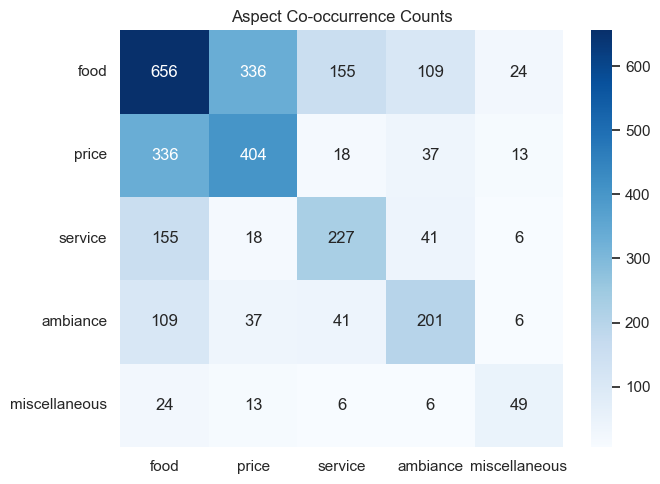

In [28]:
if sns is not None:
    plt.figure(figsize=(7, 5))
    sns.heatmap(cooccurrence, annot=True, fmt="d", cmap="Blues")
    plt.title("Aspect Co-occurrence Counts")
    plt.tight_layout()
    plt.show()
else:
    cooccurrence.plot(kind="bar", figsize=(10, 4))
    plt.title("Aspect Co-occurrence Counts")
    plt.tight_layout()
    plt.show()


In [29]:
correlation = df[ASPECT_COLUMNS].corr()
correlation


,food,price,service,ambiance,miscellaneous
food,1.000000,0.020166,-0.234423,-0.430256,-0.224907
price,0.020166,1.000000,-0.541036,-0.376042,-0.124093
service,-0.234423,-0.541036,1.000000,-0.104524,-0.092308
ambiance,-0.430256,-0.376042,-0.104524,1.000000,-0.076674
miscellaneous,-0.224907,-0.124093,-0.092308,-0.076674,1.000000


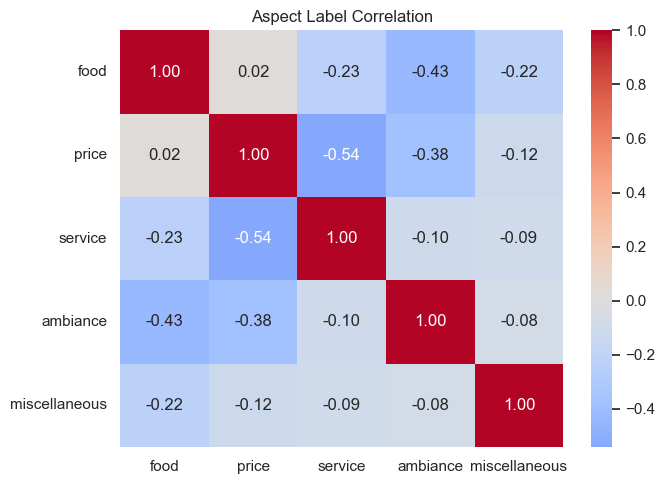

In [30]:
if sns is not None:
    plt.figure(figsize=(7, 5))
    sns.heatmap(correlation, annot=True, fmt=".2f", cmap="coolwarm", center=0)
    plt.title("Aspect Label Correlation")
    plt.tight_layout()
    plt.show()


## 6. Text Length Analysis


In [31]:
def word_count(text):
    if pd.isna(text):
        return 0
    return len(str(text).split())

def char_count(text):
    if pd.isna(text):
        return 0
    return len(str(text))

df["review_word_count"] = df["review_en"].apply(word_count)
df["cleaned_word_count"] = df["review_cleaned"].apply(word_count)
df["review_char_count"] = df["review_en"].apply(char_count)
df["cleaned_char_count"] = df["review_cleaned"].apply(char_count)

length_summary = df[
    ["review_word_count", "cleaned_word_count", "review_char_count", "cleaned_char_count"]
].describe().T
length_summary


,count,mean,std,min,25%,50%,75%,max
review_word_count,796.0,14.209799,4.373155,4.0,11.0,14.0,17.0,31.0
cleaned_word_count,796.0,6.469849,1.933575,2.0,5.0,6.0,8.0,14.0
review_char_count,796.0,72.115578,21.692342,24.0,56.0,70.0,85.0,164.0
cleaned_char_count,796.0,41.636935,13.216250,15.0,32.0,40.0,50.0,101.0


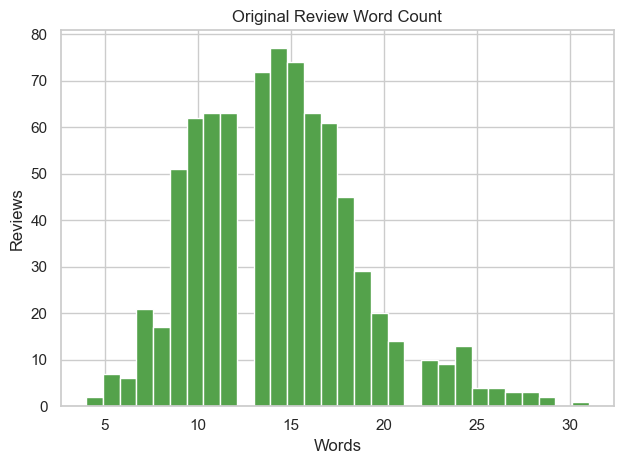

In [49]:
plt.hist(df["review_word_count"], bins=30, color="#54A24B")
plt.title("Original Review Word Count")
plt.xlabel("Words")
plt.ylabel("Reviews")


plt.tight_layout()
plt.show()


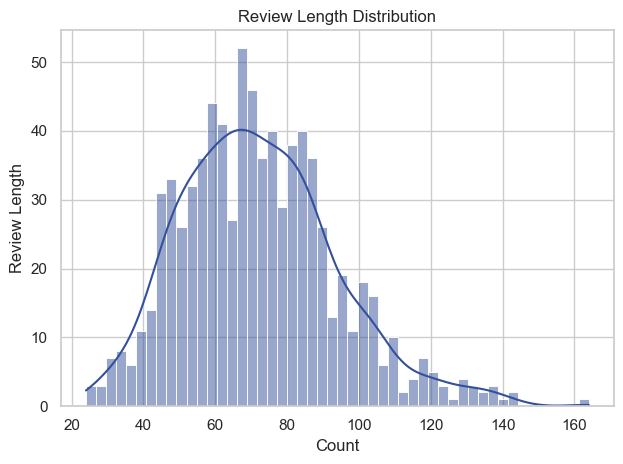

In [57]:
sns.histplot([len(r) for r in df["review_en"]], bins=50, color="#34509C", kde=True)
plt.title("Review Length Distribution")
plt.xlabel("Count")
plt.ylabel("Review Length")


plt.tight_layout()
plt.show()

In [33]:
aspect_length_summary = []
for aspect in ASPECT_COLUMNS:
    subset = df[df[aspect] == 1]
    aspect_length_summary.append({
        "aspect": aspect,
        "review_count": len(subset),
        "mean_review_words": subset["review_word_count"].mean(),
        "median_review_words": subset["review_word_count"].median(),
        "mean_cleaned_words": subset["cleaned_word_count"].mean(),
        "median_cleaned_words": subset["cleaned_word_count"].median(),
    })

aspect_length_summary = pd.DataFrame(aspect_length_summary).round(2)
aspect_length_summary


,aspect,review_count,mean_review_words,median_review_words,mean_cleaned_words,median_cleaned_words
0,food,656,14.04,14.0,6.41,6.0
1,price,404,14.23,14.0,6.46,6.0
2,service,227,14.22,14.0,6.53,6.0
3,ambiance,201,14.64,14.0,6.66,6.0
4,miscellaneous,49,14.90,14.0,6.78,7.0


## 7. Vocabulary And Frequent Terms


In [34]:
def tokenize_cleaned(text):
    if pd.isna(text):
        return []
    return re.findall(r"[a-zA-Z]+", str(text).lower())

all_tokens = [token for text in df["review_cleaned"] for token in tokenize_cleaned(text)]
token_counts = Counter(all_tokens)

vocab_summary = pd.DataFrame({
    "metric": ["total_tokens", "unique_tokens"],
    "value": [len(all_tokens), len(token_counts)],
})
vocab_summary


,metric,value
0,total_tokens,5119
1,unique_tokens,966


In [35]:
top_terms = pd.DataFrame(token_counts.most_common(30), columns=["term", "count"])
top_terms


,term,count
0,food,342
1,good,306
2,price,298
3,taste,150
4,restaurant,150
5,service,122
6,high,115
7,quality,102
8,also,100
9,bad,80


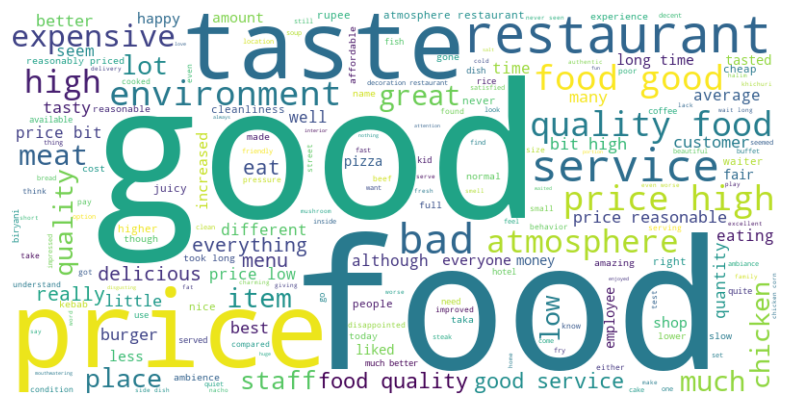

In [50]:
from wordcloud import WordCloud

# 1. Define your text data
text = " ".join(token for token in all_tokens)

# 2. Generate the word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

# 3. Display the plot using matplotlib
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # Hide the x and y axis lines/ticks
plt.show()

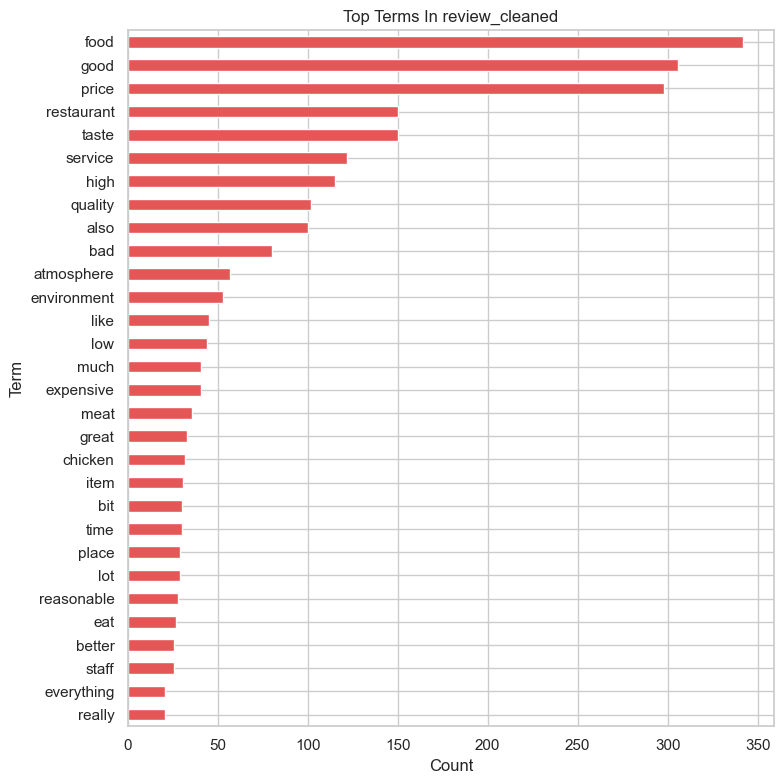

In [36]:
top_terms.sort_values("count").plot(
    x="term",
    y="count",
    kind="barh",
    legend=False,
    figsize=(8, 8),
    color="#E45756",
)
plt.title("Top Terms In review_cleaned")
plt.xlabel("Count")
plt.ylabel("Term")
plt.tight_layout()
plt.show()


In [37]:
aspect_top_terms = {}
for aspect in ASPECT_COLUMNS:
    aspect_tokens = [
        token
        for text in df.loc[df[aspect] == 1, "review_cleaned"]
        for token in tokenize_cleaned(text)
    ]
    aspect_top_terms[aspect] = pd.DataFrame(
        Counter(aspect_tokens).most_common(15),
        columns=["term", "count"],
    )

aspect_top_terms["miscellaneous"]


,term,count
0,food,25
1,good,25
2,restaurant,20
3,price,10
4,location,6
5,also,6
6,everything,6
7,taste,5
8,like,5
9,else,5


## 8. Suspicious Records For Manual Review


In [38]:
keyword_map = {
    "food": r"\b(food|taste|tasty|delicious|dish|meal|meat|chicken|beef|rice|burger|pizza|coffee|soup|cake|menu|quality|portion|fresh|stale|raw|cooked)\b",
    "price": r"\b(price|priced|cost|costs|cheap|expensive|affordable|reasonable|money|bill|value|tk|taka|rupee|rupees|budget)\b",
    "service": r"\b(service|served|serving|staff|waiter|waiters|waitstaff|behavior|delivery|wait|waited|slow|quick|promptly|manager|order)\b",
    "ambiance": r"\b(environment|ambience|ambiance|atmosphere|interior|decor|decoration|place|space|clean|dirty|bathroom|location|restaurant|family|kid|kids|mosquito|smell)\b",
}

suspicious_frames = []
for aspect, pattern in keyword_map.items():
    mentions_aspect = df["review_en"].str.contains(pattern, case=False, na=False, regex=True)
    missing_label = df[aspect] == 0
    suspicious = df.loc[mentions_aspect & missing_label, ["review_en", "review_cleaned", *ASPECT_COLUMNS]].copy()
    suspicious["suspected_missing_aspect"] = aspect
    suspicious_frames.append(suspicious)

suspicious_missing_labels = pd.concat(suspicious_frames, ignore_index=True)
print(f"Potential missing aspect labels: {len(suspicious_missing_labels):,}")
suspicious_missing_labels.head(30)


Potential missing aspect labels: 113


C:\Users\ASUS ZENBOOK\AppData\Local\Temp\ipykernel_20072\358245340.py:10: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mentions_aspect = df["review_en"].str.contains(pattern, case=False, na=False, regex=True)
C:\Users\ASUS ZENBOOK\AppData\Local\Temp\ipykernel_20072\358245340.py:10: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mentions_aspect = df["review_en"].str.contains(pattern, case=False, na=False, regex=True)
C:\Users\ASUS ZENBOOK\AppData\Local\Temp\ipykernel_20072\358245340.py:10: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mentions_aspect = df["review_en"].str.contains(pattern, case=False, na=False, regex=True)
C:\Users\ASUS ZENBOOK\AppData\Local\Temp\ipykernel_20072\358245340.py:10: UserWarning: This pattern is 

,review_en,review_cleaned,food,price,service,ambiance,miscellaneous,suspected_missing_aspect
0,food prices are relatively low and relatively higher than other places,food price relatively low relatively higher place,0,1,0,0,0,food
1,the price of the food is not reasonable but i am satisfied with the service,price food reasonable satisfied service,0,1,1,0,0,food
2,good atmosphere to hangout but food price is high,good atmosphere hangout food price high,0,1,0,1,0,food
3,the location of the restaurant is good and the price of the food is also low,location restaurant good price food also low,0,1,0,0,1,food
4,the food is not expensive and there is a good atmosphere for dining with the family,food expensive good atmosphere dining family,0,1,0,1,0,food
5,the decoration of the restaurant is better than before but the price of all the food has increased a bit,decoration restaurant better price food increased bit,0,1,0,1,0,food
6,there were many combinations on the menu and the prices were reasonable,many combination menu price reasonable,0,1,0,0,1,food
7,lack of professionalism among the staff and food prices are too high,lack professionalism among staff food price high,0,1,1,0,0,food
8,the ambience of the restaurant is good and that is why the food prices seem so high,ambience restaurant good food price seem high,0,1,0,1,0,food
9,this is the best place and the food is very reasonably priced,best place food reasonably priced,0,1,0,1,0,food


In [39]:
no_label_rows = df[df["label_count"] == 0].copy()
print(f"Rows with no positive label: {len(no_label_rows):,}")
no_label_rows[["review_en", "review_cleaned", *ASPECT_COLUMNS]].head(30)


Rows with no positive label: 0


,review_en,review_cleaned,food,price,service,ambiance,miscellaneous


In [40]:
short_reviews = df.nsmallest(20, "review_word_count")[
    ["review_en", "review_cleaned", "review_word_count", *ASPECT_COLUMNS]
]
short_reviews


,review_en,review_cleaned,review_word_count,food,price,service,ambiance,miscellaneous
14,great food great service,great food great service,4,1,0,1,0,0
15,great food crappy service,great food crappy service,4,1,0,1,0,0
20,good coffee or quiet environment,good coffee quiet environment,5,1,0,0,1,0
80,quiet place and good service,quiet place good service,5,0,0,1,1,0
175,bad food and bad service,bad food bad service,5,1,0,1,0,0
438,no environment and no service,environment service,5,0,0,1,1,0
573,toxic environment and poor service,toxic environment poor service,5,0,0,1,1,0
680,delicious food and affordable too,delicious food affordable,5,1,1,0,0,0
716,biryani was ok but underpriced,biryani ok underpriced,5,1,1,0,0,0
13,dirty service and a clean bathroom,dirty service clean bathroom,6,0,0,1,1,0


In [41]:
long_reviews = df.nlargest(20, "review_word_count")[
    ["review_en", "review_cleaned", "review_word_count", *ASPECT_COLUMNS]
]
long_reviews


,review_en,review_cleaned,review_word_count,food,price,service,ambiance,miscellaneous
568,it is necessary to sell the land and go here to eat the price of food is so high but everyone goes here to get the touch of a good environment,necessary sell land go eat price food high everyone go get touch good environment,31,0,1,0,1,0
428,i do not understand how the staff of the restaurant handled so many customers and the atmosphere of the restaurant was very quiet even though there were man...,understand staff restaurant handled many customer atmosphere restaurant quiet even though many people,29,0,0,1,1,0
437,the food was not as good as i thought it was high quality food in a word the taste was normal but the price was not cheap at all,food good thought high quality food word taste normal price cheap,29,1,1,0,0,0
478,they gave us welcome drinks as soon as we sat in the restaurant which i like very much and the rest of their service was also very good,gave u welcome drink soon sat restaurant like much rest service also good,28,1,0,1,0,0
556,today i ate here and realized that the lack of salt in the food spoils the taste of the food and there were many mistakes in their serving,today ate realized lack salt food spoil taste food many mistake serving,28,1,0,1,0,0
564,if the khichuri here is not available in the rain i do not like the taste of their khichuri but it takes a lot of time to deliver,khichuri available rain like taste khichuri take lot time deliver,28,1,0,1,0,0
414,although the price here is lower than the neighboring shops but the taste of the food is not so good so people gather in the neighboring shops,although price lower neighboring shop taste food good people gather neighboring shop,27,1,1,0,0,0
456,the ac in the restaurant is not working and all the customers are in a bad mood as they wait for a long time for the food,ac restaurant working customer bad mood wait long time food,27,0,0,1,1,0
569,they are giving free toys to children which is good for marketing but the price of food is high and the price of toys is being collected,giving free toy child good marketing price food high price toy collected,27,0,1,0,0,1
420,if everything is good at the wifes favorite restaurant and especially if the price of the food there is low then what else do husbands need,everything good wife favorite restaurant especially price food low else husband need,26,0,1,0,0,1


## 9. Save EDA Outputs


In [42]:
schema_summary.to_csv(OUTPUT_DIR / "schema_summary.csv", index=False)
label_values_df.to_csv(OUTPUT_DIR / "label_value_summary.csv")
aspect_distribution.to_csv(OUTPUT_DIR / "aspect_distribution.csv", index=False)
label_count_distribution.to_csv(OUTPUT_DIR / "label_count_distribution.csv", index=False)
combo_distribution.to_csv(OUTPUT_DIR / "aspect_combination_distribution.csv", index=False)
cooccurrence.to_csv(OUTPUT_DIR / "aspect_cooccurrence.csv")
correlation.to_csv(OUTPUT_DIR / "aspect_correlation.csv")
length_summary.to_csv(OUTPUT_DIR / "text_length_summary.csv")
aspect_length_summary.to_csv(OUTPUT_DIR / "aspect_length_summary.csv", index=False)
top_terms.to_csv(OUTPUT_DIR / "top_terms.csv", index=False)
suspicious_missing_labels.to_csv(OUTPUT_DIR / "suspicious_missing_aspect_labels.csv", index=False)
duplicate_reviews.to_csv(OUTPUT_DIR / "duplicate_reviews.csv", index=False)

print(f"Saved EDA outputs to: {OUTPUT_DIR.resolve()}")


Saved EDA outputs to: D:\ZB\Code\UIT\CS221\outputs\EDA


## 10. Notes For Modeling

Use the generated summary files to decide the next modeling actions:
- if `miscellaneous` is rare, tune thresholds and class weights for that class separately
- if label co-occurrence is strong, keep multi-label methods such as One-vs-Rest instead of forcing one class
- inspect `suspicious_missing_aspect_labels.csv` before final training because noisy labels directly reduce F1
- keep `review_en` for SBERT models; use `review_cleaned` mainly for TF-IDF and vocabulary diagnostics
